Сетевой анализ персонажей Disco Elysium: как нарративная позиция формирует положение в сети совместных появлений

Курс: "Цифровые технологии в профессиональной деятельности", ФГН НИУ ВШЭ, 2026
Финальный проект

1. Исследовательский вопрос

Как нарративная позиция персонажа (вводный эпизод, основная часть игры, разрешение сюжета) формирует его положение в сети совместных появлений с другими персонажами?

Материал - компьютерная игра *Disco Elysium* (ZA/UM, 2019): нелинейная детективная RPG с диалоговой системой, построенной на ветвящихся сценах (`conversationid`) и более 400 поименно названных действующих лиц.

Ответ распадается на три части:

1. Проверка, что сеть совместных появлений вообще несет социальный сигнал, а не артефакт способа сбора данных.
2. Временной вопрос: как состав и структура сети меняются по ходу игры. Решается двумя методами, потому что сама игра кодирует время по-разному на разных участках - на раннем этапе явной игровой переменной дня, к финалу переменной завершенности квеста.
3. Устойчивость самого метода - отдельная проверка, не смешивается с содержательными результатами.

2. Предыдущие исследования

Методологический ориентир - Beveridge, A. & Shan, J. (2016). *Network of Thrones*. Math Horizons. Авторы строят сеть co-occurrence персонажей "Игры престолов" по книгам, считают degree/betweenness centrality и используют расхождение между ними как индикатор структурно значимых, но не самых "многословных" персонажей (пример из их работы - Robert Baratheon).

Целенаправленный поиск (по состоянию на июнь 2026) не обнаружил количественных/сетевых работ по Disco Elysium - есть качественные литературоведческие работы (сборник Post45, статья в First Person Scholar об агентности игрока, социолингвистическое исследование акцентов персонажей), но не сетевой анализ.

3. Данные

Источник - датамайнинговый дамп диалоговой базы игры: [github.com/msyavuz/disco-api](https://github.com/msyavuz/disco-api), файл `disco.db` (SQLite, ≈40 МБ).

Ключевые таблицы:

| Таблица | Содержание | Объем |
|---|---|---|
| `dentries` | строки диалога: `conversationid`, `actor`, `conversant`, `dialoguetext`, `conditionstring` | 77 290 строк |
| `actors` | id и имя действующего лица (персонажи, голоса навыков психики, предметы) | 421 строка |
| `dialogues` | id и название сцены (кодирует локацию/тему) | 1 428 строк |
| `dlinks` | переходы между диалоговыми узлами, в т.ч. межсценовые | 134 491 строка |

Ниже - загрузка файла в pandas; SQLite используется только для чтения, дальнейшая обработка - через pandas и networkx.

In [1]:
import sqlite3
import os
import requests

DB_PATH = "data/disco.db"
DB_URL = "https://raw.githubusercontent.com/msyavuz/disco-api/main/disco.db"

if not os.path.exists(DB_PATH):
    os.makedirs("data", exist_ok=True)
    print("качаем.")
    r = requests.get(DB_URL)
    with open(DB_PATH, "wb") as f:
        f.write(r.content)

import pandas as pd

conn = sqlite3.connect(DB_PATH)
dentries = pd.read_sql_query("SELECT conversationid, actor, conditionstring FROM dentries", conn)
actors = pd.read_sql_query("SELECT id, name FROM actors", conn)
dialogues = pd.read_sql_query("SELECT id, title FROM dialogues", conn)
dlinks = pd.read_sql_query("SELECT originconversationid, destinationconversationid FROM dlinks", conn)
conn.close()

names = dict(zip(actors["id"], actors["name"]))
print(f"dentries: {dentries.shape[0]} строк")
print(f"actors: {actors.shape[0]} строк")
print(f"dialogues: {dialogues.shape[0]} строк")

dentries: 77290 строк
actors: 421 строк
dialogues: 1428 строк


4. Метод

4.1 Определение ребра

Первая гипотеза - ребро = пара `actor → conversant` - была проверена и отвергнута: поле `conversant` часто кодирует тему или объект разговора, а не реального собеседника (пример: в одной сцене и Гарри, и Ким говорят, а `conversant` указывает на "Coin-Operated Viewer" - автомат для монет).

Принятое определение: ребро = совместное появление двух разных `actor` (говорящих) в пределах одной сцены (`conversationid`), вес - число сцен, где пара встретилась вместе. Это прямой аналог метода Beveridge & Shan и формата лабораторной работы по "Ведьмаку" (семинар 7), адаптированный к структуре данных конкретной игры (там единица - окно ±5 строк текста, здесь - диалоговая сцена, потому что у игры нет сплошного текста, только дискретные ветвящиеся сцены).

4.2 Чистка действующих лиц

`actors` содержит не только персонажей: служебный null-актор для джойнов (id=0), маркер ветвления (id=388) и 24 голоса навыков психики персонажа (id 389-420, например Логика, Восприятие) - категориально не являются ни персонажами, ни предметами мира игры, исключены при любом уровне чистки.

Кроме того, среди оставшихся после этого 387 акторов есть "говорящие предметы" (Necktie, двери, мебель). Полный ручной аудит дал два варианта:
- строгая чистка: предметы тоже исключены (используется как основная сеть для проверки валидности и финального сравнения);
- слабая чистка: предметы оставлены (используется для временной оси, см. раздел 6 про инфляцию степени).

4.3 Поиск временной оси: отвергнутые подходы

Перепробованы и отвергнуты по эмпирическим основаниям:
- локация как признак этапа игры: хаб "Whirling" используется на всем протяжении игры, включая поздние сцены;
- записи квестового журнала как ранний якорь: у этих `conversationid` нет ни одной строки в `dentries` (другая популяция данных);
- граф переходов `dlinks` сам по себе: слишком разрежен (158 узлов из 585, 29 несвязных компонент);
- внешний walkthrough как канонический порядок: игра прямо описывается как нелинейная, единого порядка не существует.

Рабочее решение нашлось в `conditionstring`: игра использует явные функции `DayCount()`, `IsDayFrom(N)`, `IsDayUntil(N)`, а также имена переменных вида `_day_N`. Это дало 30 сцен с прямым тэгом дня. Покрытие расширено до 63 сцен через одношаговую propagation по графу `dlinks` (если непомеченная сцена напрямую связана переходом с тэгированной - ей присваивается тот же день), с проверкой на непротиворечивость: если у непомеченной сцены несколько тэгированных соседей с разными днями - она не размечается. Конфликтов не возникло (33 из 33 пропагированных сцены согласованны).

Для финала (локация Seafort) такого покрытия нет вообще - ни одна из 95 сцен Seafort не несет day-тэга. Игра к этому моменту гейтит контент не по дню, а по условию завершенности квеста (`TASK.inspect_the_phasmid_done`). Сцены Seafort отбираются по префиксу названия диалога (`SEAFORT%`); условие `TASK.inspect_the_phasmid_done` проверяет однократный гейт входа в локацию, а не каждую сцену по отдельности, поэтому привязка финала к этому условию менее точна, чем привязка сцен к дням.

In [2]:
STRONG_EXCLUDE = {0, 388, 367, 244,229,141,212,202,215,282,147,275,383,96,384,285,204,358,125,308,207,382,366,269,
111,301,315,201,228,146,257,303,279,154,79,306,153,233,243,193,94,252,296,334,381,
251,290,311,307,316,327,337,375,155,219,373,374,376,50,280,294,356,370,247,313,333,
338,131,160,246,329,363,97,132,203,240,248,288,300,86,261,265,324,332,368,220,291,
298,198,238,385,216,217,218,221,245,259,310,330,250,254,255,345,353,369,200,256,314,
350,361,386,295,309,318,320,326,365,234,335,339,341,348,349,372,225,264,274,278,297,
328,344,357,239,277,289,319,343,362,378,284,286,323,354,205,287,292,321,340,346,360,
242,249,276,304,347,377,379,206,237,317,322,331,351,352,355,209,222,223,302,305,336,
359,89,156,260,266,273,342,67,95,17,127} | set(range(389, 421))

WEAK_EXCLUDE = {0, 388} | set(range(389, 421))

print(f"Строгая чистка исключает {len(STRONG_EXCLUDE)} id (служебные + навыки + предметы)")
print(f"Слабая чистка исключает {len(WEAK_EXCLUDE)} id (только служебные + навыки)")

Строгая чистка исключает 214 id (служебные + навыки + предметы)
Слабая чистка исключает 34 id (только служебные + навыки)


In [3]:
from itertools import combinations

def build_edges_df(exclude_ids, conv_ids=None):
    """Строит таблицу ребер (source, target, weight): группирует строки по сцене,
    берет уникальных говорящих, считает все пары, суммирует по парам через pandas.groupby."""
    df = dentries[~dentries["actor"].isin(exclude_ids)].copy()
    if conv_ids is not None:
        df = df[df["conversationid"].isin(conv_ids)]
    df["name"] = df["actor"].map(names)
    scene_speakers = df.groupby("conversationid")["name"].apply(lambda s: sorted(set(s)))
    rows = [(a, b) for speakers in scene_speakers for a, b in combinations(speakers, 2)]
    pair_df = pd.DataFrame(rows, columns=["source", "target"])
    return pair_df.groupby(["source", "target"], as_index=False).size().rename(columns={"size": "weight"})

edges_full = build_edges_df(STRONG_EXCLUDE)
edges_full.to_csv("data/edges_full_strict.csv", index=False)
print(f"Ребер построено: {len(edges_full)}, сохранено в data/edges_full_strict.csv")
edges_full.head()

Ребер построено: 368, сохранено в data/edges_full_strict.csv


,source,target,weight
0,Acele,Andre,7
1,Acele,Egg Head,6
2,Acele,Kim Kitsuragi,11
3,Acele,Noid,7
4,Acele,"Soona, the Programmer",5


5. Результаты

5.1 Сеть как объект

In [4]:
import networkx as nx

G = nx.Graph()
for _, row in edges_full.iterrows():
    G.add_edge(row["source"], row["target"], weight=row["weight"])

print(f"Узлов: {G.number_of_nodes()}")
print(f"Ребер: {G.number_of_edges()}")
print(f"Плотность: {nx.density(G):.4f}")

Узлов: 105
Ребер: 368
Плотность: 0.0674


In [5]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

metrics_df = pd.DataFrame({
    "name": list(G.nodes()),
    "degree": [G.degree(n) for n in G.nodes()],
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()],
})

print("Топ-10 по degree centrality:")
print(metrics_df.sort_values("degree_centrality", ascending=False).head(10)[["name", "degree_centrality"]].to_string(index=False))
print()
print("Топ-10 по betweenness centrality:")
print(metrics_df.sort_values("betweenness_centrality", ascending=False).head(10)[["name", "betweenness_centrality"]].to_string(index=False))

metrics_df.to_csv("data/metrics_full_strict.csv", index=False)
print()
print("Сохранено в data/metrics_full_strict.csv")

Топ-10 по degree centrality:
                        name  degree_centrality
                         You           0.826923
               Kim Kitsuragi           0.817308
Garte, the Cafeteria Manager           0.173077
                Titus Hardie           0.144231
                       Alain           0.144231
                        Cuno           0.144231
                      Eugene           0.144231
                   Elizabeth           0.134615
                The Gardener           0.134615
                        Glen           0.134615

Топ-10 по betweenness centrality:
                        name  betweenness_centrality
                         You                0.319755
               Kim Kitsuragi                0.303885
                        Scab                0.007588
                        Cuno                0.004061
Garte, the Cafeteria Manager                0.002840
             Chester McLaine                0.001147
                       Alice         

Ошибка метода, зафиксированная и исправленная в процессе работы: в одной из промежуточных версий betweenness считалась как `nx.betweenness_centrality(G, weight="weight")`. В networkx параметр `weight` интерпретируется как расстояние, а не как сила связи - передавая туда частоту совместных появлений напрямую, мы тем самым говорили алгоритму "чем чаще два персонажа видятся, тем дальше они друг от друга", что перевернуто. Из-за этого процедура находила структурно незначимого персонажа (degree 3, одна случайная сцена) как "скрытый мост": артефакт интерпретации параметра weight, ничего не говорящий о реальной структуре сети. В коде выше betweenness считается без `weight`, как в материалах семинара 7: лидеры по degree и по betweenness совпадают (Гарри и Ким), что для игры с двумя сквозными протагонистами, присутствующими почти в каждой сцене, ожидаемо.

Силовая раскладка pyvis в визуализации ниже визуально группирует тесно связанные подгруппы персонажей: отдельно выделяются группа забастовки докеров, церковный круг и трио криптозоологов. Наблюдение сделано по расположению узлов на графике, без алгоритмической детекции сообществ; группировка совпадает с сюжетным и географическим разделением этих персонажей в игре.

In [6]:
from pyvis.network import Network
from IPython.display import IFrame, display

for node in G.nodes():
    G.nodes[node]["size"] = 10 + degree_centrality[node] * 80
    G.nodes[node]["title"] = (
        f"{node}\n"
        f"Degree centrality: {degree_centrality[node]:.3f}\n"
        f"Betweenness: {betweenness_centrality[node]:.3f}"
    )
    G.nodes[node]["color"] = "#e8a838" if node in ("You", "Kim Kitsuragi") else "#4a90d9"

for u, v, data in G.edges(data=True):
    data["width"] = data["weight"] ** 0.5

net = Network(height="700px", width="100%", bgcolor="#1a1a2e", font_color="white")
net.from_nx(G)
net.show_buttons(filter_=["physics"])
net.write_html("viz/full_network.html")

display(IFrame(src="viz/full_network.html", width="100%", height="700"))

Интерактивная сеть встроена выше через IFrame. Статичного дубликата для нее нет: при 105 узлах и двух хабах (Гарри, Ким), каждый связанный с ~80% сети, стандартные раскладки (spring_layout, kamada_kawai_layout) дают нечитаемое скопление подписей в центре. Результаты раздела - таблицы top-10 по degree и betweenness выше; визуализация - в файле `viz/full_network.html`.

5.2 Временная ось

In [7]:
import re
from collections import defaultdict

day_pattern = re.compile(r'DayCount\(\)\s*(==|>=|<=|>|<)\s*(\d+)')
isdayfrom_pattern = re.compile(r'IsDayFrom\((\d+)\)')
isdayuntil_pattern = re.compile(r'IsDayUntil\((\d+)\)')
varname_day_pattern = re.compile(r'_day_(\d)\b')

cond = dentries.dropna(subset=["conditionstring"])
scene_days = defaultdict(set)
for cid, cs in zip(cond["conversationid"], cond["conditionstring"]):
    for op, val in day_pattern.findall(cs): scene_days[cid].add(int(val))
    for val in isdayfrom_pattern.findall(cs): scene_days[cid].add(int(val))
    for val in isdayuntil_pattern.findall(cs): scene_days[cid].add(int(val))
    for val in varname_day_pattern.findall(cs): scene_days[cid].add(int(val))

min_day = {cid: min(d) for cid, d in scene_days.items()}
tagged_ids = set(min_day.keys())
print(f"Сцен с прямым day-тэгом: {len(tagged_ids)}")

Сцен с прямым day-тэгом: 30


In [8]:
# propagation: если непомеченная сцена связана переходом dlinks с тэгированной - присваиваем тот же день,
# но только если ВСЕ тэгированные соседи согласны об одном дне (проверка на непротиворечивость)
cross = dlinks[dlinks["originconversationid"] != dlinks["destinationconversationid"]].dropna()
neighbors = defaultdict(set)
for o, d in zip(cross["originconversationid"], cross["destinationconversationid"]):
    neighbors[o].add(d)
    neighbors[d].add(o)

propagated_days = defaultdict(set)
for cid in tagged_ids:
    for n in neighbors.get(cid, []):
        if n not in tagged_ids:
            propagated_days[n].add(min_day[cid])

consistent = {cid: list(days)[0] for cid, days in propagated_days.items() if len(days) == 1}
conflicting = {cid: days for cid, days in propagated_days.items() if len(days) > 1}
print(f"Согласованных пропагированных сцен: {len(consistent)}")
print(f"Конфликтующих (отброшены): {len(conflicting)}")

final_day = dict(min_day)
final_day.update(consistent)
print(f"Итоговое покрытие: {len(final_day)} сцен из {dentries['conversationid'].nunique()} ({100*len(final_day)/dentries['conversationid'].nunique():.1f}%)")

Согласованных пропагированных сцен: 33
Конфликтующих (отброшены): 0


Итоговое покрытие: 63 сцен из 590 (10.7%)


In [9]:
edges_day = build_edges_df(WEAK_EXCLUDE, conv_ids=set(final_day.keys()))
edges_day.to_csv("data/edges_day_axis.csv", index=False)

import json
with open("data/final_day_tags.json", "w") as f:
    json.dump({str(k): v for k, v in final_day.items()}, f)

G_day = nx.Graph()
for _, row in edges_day.iterrows():
    G_day.add_edge(row["source"], row["target"], weight=row["weight"])

print(f"Сеть временной оси: {G_day.number_of_nodes()} узлов, {G_day.number_of_edges()} ребер")

# день первого появления каждого персонажа - для кривой роста и цвета на визуализации
# фильтрация по WEAK_EXCLUDE делается ДО маппинга id -> имя (та же чистка, что и для edges_day)
dentries_clean = dentries[~dentries["actor"].isin(WEAK_EXCLUDE)].copy()
dentries_clean["name"] = dentries_clean["actor"].map(names)

first_day = {}
seen = set()
new_per_day = {}
for d in sorted(set(final_day.values())):
    conv_this_day = [cid for cid, dd in final_day.items() if dd == d]
    nodes_today = set(dentries_clean[dentries_clean["conversationid"].isin(conv_this_day)]["name"])
    new_today = nodes_today - seen
    new_per_day[d] = len(new_today)
    for n in new_today:
        first_day[n] = d
    seen |= nodes_today

print("Новых персонажей/предметов по дням:")
for d, c in new_per_day.items():
    print(f"  день {d}: {c}")

Сеть временной оси: 39 узлов, 171 ребер
Новых персонажей/предметов по дням:
  день 1: 12
  день 2: 25
  день 3: 4
  день 4: 0
  день 5: 1


In [10]:
for node in G_day.nodes():
    deg_c_day = nx.degree_centrality(G_day)
    G_day.nodes[node]["size"] = 10 + deg_c_day[node] * 80
    d = first_day.get(node, 1)
    day_colors = {1: "#7F77DD", 2: "#378ADD", 3: "#1D9E75", 4: "#BA7517", 5: "#D85A30"}
    G_day.nodes[node]["color"] = day_colors.get(d, "#aaaaaa")
    G_day.nodes[node]["title"] = f"{node}\nДень первого появления: {d}"

for u, v, data in G_day.edges(data=True):
    data["width"] = data["weight"] ** 0.5

net_day = Network(height="600px", width="100%", bgcolor="#0f0f23", font_color="#eeeeee")
net_day.from_nx(G_day)
net_day.show_buttons(filter_=["physics"])
net_day.write_html("viz/day_axis_network.html")

display(IFrame(src="viz/day_axis_network.html", width="100%", height="600"))

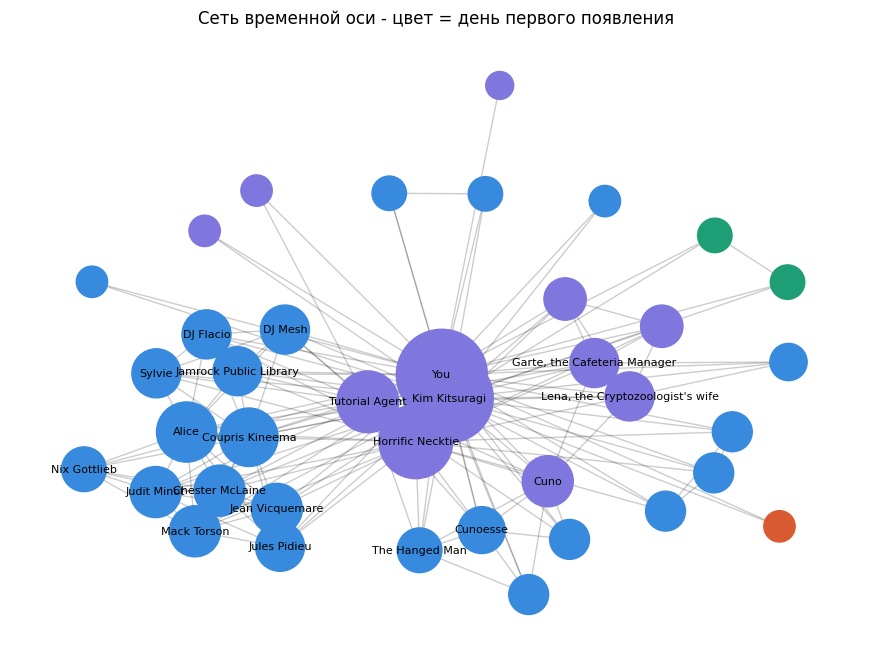

In [11]:
# статичный дубликат визуализации (раздел 5.2)
import matplotlib.pyplot as plt

pos_day = nx.spring_layout(G_day, k=0.4, seed=42)
day_colors = {1: "#7F77DD", 2: "#378ADD", 3: "#1D9E75", 4: "#BA7517", 5: "#D85A30"}
node_colors_day = [day_colors.get(first_day.get(n, 1), "#aaaaaa") for n in G_day.nodes()]
node_sizes_day = [300 + nx.degree_centrality(G_day)[n] * 4000 for n in G_day.nodes()]

plt.figure(figsize=(11, 8))
nx.draw_networkx_edges(G_day, pos_day, alpha=0.2)
nx.draw_networkx_nodes(G_day, pos_day, node_size=node_sizes_day, node_color=node_colors_day)
nx.draw_networkx_labels(G_day, pos_day, labels={n: n for n in G_day.nodes() if G_day.degree(n) >= 7}, font_size=8)
plt.title("Сеть временной оси - цвет = день первого появления")
plt.axis("off")
plt.savefig("viz/day_axis_network_static.png", dpi=150, bbox_inches="tight")
plt.show()

Картина по дням: взрывной ввод состава на 1-2 день, резкое затухание на 3-й, почти ноль на 4-5. Это согласуется с устройством игры: социальный мир выстраивается в первые двое суток, дальше сюжет работает в основном с уже введенным составом.

Оговорка: эта сеть построена при слабой чистке - отличается от сети раздела 5.1 не только выборкой сцен, но и способом чистки действующих лиц. Ее результаты согласуются с общей структурой полной сети; самостоятельной проверки на валидность они не проходили (см. ограничения, п. 1).

5.3 Финал (Seafort)

In [12]:
seafort_ids = set(dialogues[dialogues["title"].str.startswith("SEAFORT", na=False)]["id"])
all_conv_ids = set(dentries["conversationid"].unique())
rest_ids = all_conv_ids - seafort_ids

edges_seafort = build_edges_df(STRONG_EXCLUDE, conv_ids=seafort_ids)
edges_rest = build_edges_df(STRONG_EXCLUDE, conv_ids=rest_ids)
edges_seafort.to_csv("data/edges_seafort.csv", index=False)
edges_rest.to_csv("data/edges_rest.csv", index=False)

G_seafort = nx.Graph()
for _, row in edges_seafort.iterrows():
    G_seafort.add_edge(row["source"], row["target"], weight=row["weight"])

rest_nodes = set(edges_rest["source"]) | set(edges_rest["target"])
seafort_nodes = set(G_seafort.nodes())
new_in_finale = seafort_nodes - rest_nodes

print(f"Сцен Seafort: {len(seafort_ids)}")
print(f"Персонажей в финале: {len(seafort_nodes)}")
print(f"Из них новых (нет в остальной игре): {len(new_in_finale)} -> {new_in_finale}")
print(f"Доля новых от состава финала: {100*len(new_in_finale)/len(seafort_nodes):.0f}%")

Сцен Seafort: 95
Персонажей в финале: 5
Из них новых (нет в остальной игре): 2 -> {'Insulindian Phasmid', 'The Deserter'}
Доля новых от состава финала: 40%


In [13]:
deg_c_sf = nx.degree_centrality(G_seafort)
for node in G_seafort.nodes():
    G_seafort.nodes[node]["size"] = 15 + deg_c_sf[node] * 80
    is_new = node in new_in_finale
    G_seafort.nodes[node]["color"] = "#e8584a" if is_new else "#4a90d9"
    G_seafort.nodes[node]["title"] = f"{node}\n{'новый персонаж' if is_new else 'уже встречался ранее'}"

for u, v, data in G_seafort.edges(data=True):
    data["width"] = data["weight"] ** 0.5

net_sf = Network(height="400px", width="100%", bgcolor="#1a1a2e", font_color="white")
net_sf.from_nx(G_seafort)
net_sf.write_html("viz/seafort_network.html")

display(IFrame(src="viz/seafort_network.html", width="100%", height="400"))

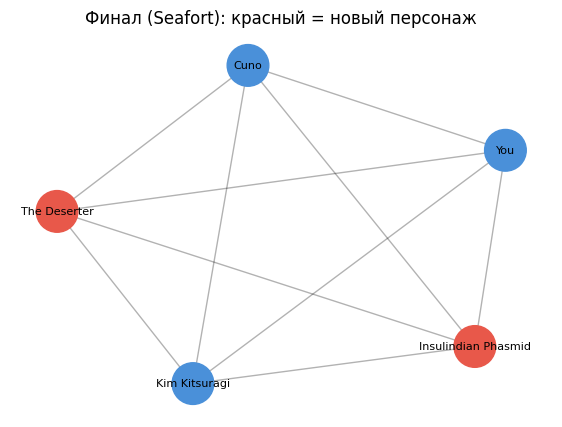

In [14]:
# статичный дубликат визуализации
pos_sf = nx.spring_layout(G_seafort, seed=42)
node_colors_sf = ["#e8584a" if n in new_in_finale else "#4a90d9" for n in G_seafort.nodes()]

plt.figure(figsize=(7, 5))
nx.draw_networkx_edges(G_seafort, pos_sf, alpha=0.3)
nx.draw_networkx_nodes(G_seafort, pos_sf, node_size=900, node_color=node_colors_sf)
nx.draw_networkx_labels(G_seafort, pos_sf, font_size=8)
plt.title("Финал (Seafort): красный = новый персонаж")
plt.axis("off")
plt.savefig("viz/seafort_network_static.png", dpi=150, bbox_inches="tight")
plt.show()

Из 5 персонажей финала двое - Дезертир и Инсулиндийский Фазмид - отсутствуют во всей остальной сети, при том что они входят в число центральных фигур основной разгадки. Выборка финала - 5 узлов, слишком мало для статистической значимости в строгом смысле, но наблюдение содержательно: даже в крошечном финальном составе почти половина - впервые появляющиеся фигуры, и обе напрямую связаны с разрешением основной интриги.

In [15]:
# Проверка устойчивости: насколько слабая чистка (раздел 5.2) раздувает degree
# по сравнению со строгой чисткой (раздел 5.1) - для тех же персонажей
edges_weak_full = build_edges_df(WEAK_EXCLUDE)

G_weak_full = nx.Graph()
for _, row in edges_weak_full.iterrows():
    G_weak_full.add_edge(row["source"], row["target"], weight=row["weight"])

inflation = []
for n in G.nodes():  # G - строгая сеть из раздела 5.1
    d_strict = G.degree(n)
    d_weak = G_weak_full.degree(n) if n in G_weak_full else d_strict
    inflation.append(d_weak - d_strict)

avg_inflation = sum(inflation) / len(inflation)
avg_degree_strict = sum(dict(G.degree()).values()) / G.number_of_nodes()

print(f"Среднее увеличение degree на персонажа при слабой чистке: {avg_inflation:.2f}")
print(f"В процентах от среднего degree в строгой сети: {100 * avg_inflation / avg_degree_strict:.1f}%")

Среднее увеличение degree на персонажа при слабой чистке: 5.00
В процентах от среднего degree в строгой сети: 71.3%


6. Ограничения и перспективы

1. Проверка валидности (раздел 5.1) сделана на сети со строгой чисткой. Сеть временной оси (5.2) построена иначе - со слабой чисткой и на значительно меньшей выборке сцен. 
2. Слабая чистка раздувает степень персонажей в среднем на ~70% (вычислено в ячейке выше) - за счет говорящих предметов и протагониста/Кима, которые присутствуют почти в каждой сцене и поэтому формально "совместно появляются" с любым предметом в кадре.

3. Покрытие временной оси - 63 из 590 сцен (10.7%). Это потолок метода, остальная игра структурно не привязана к конкретному дню (открытый мир по дизайну). Распространение на два и более шага по `dlinks` дала бы больше сцен, но с резко падающей надежностью.

4. Список исключенных действующих лиц построен через гпт аудит и содержит небесспорные решения (например, "повешенный" оставлен как персонаж, хотя физически мертв и существует как видение).

5. Ошибка с весом в betweenness и ее диагностика (раздел 5.1) задокументированы как часть метода.

Перспективы. Текстовый анализ содержания диалоговых строк (а не только факта совместного появления) мог бы дать более тонкую характеристику типа связи между персонажами. Двухшаговая propagation с понижающимся весом доверия могла бы немного расширить покрытие временной оси при явном указании этой меньшей надежности.